**Data Preparation**

Data preparation is the most critical step before any ML/DL model. A clean, well-prepared dataset often matters similar to the choice of suitable algorithm.

**Goal:** Prepare raw data suitable for modelling or analysis.

**Data Preprocessing**

Data preprocessing is the step where raw data is transformed into model-ready data. Poor preprocessing = poor model, no matter how advanced the algorithm.

Good preprocessing beats complex models.
A simple model on clean data often outperforms a complex model on messy data.

Identify potential noise in the dataset and apply appropriate preprocessing techniques to address it.

Refer TOPIC 02 especially SLIDE 07, 15-19

**Data Understanding and Initial Cleaning**

In [11]:
# Import the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

In [12]:
# Import the dataset
dataset = pd.read_csv('C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 3 - Data Preprocessing/Data.csv')
dataset

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,NaN,35.0,58000.0,Yes
6,France,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [13]:
dataset.dtypes

Country       object
Age          float64
Salary       float64
Purchased     object
dtype: object

In [14]:
dataset.shape

(10, 4)

In [15]:
# Detect missing values
dataset.isnull().sum() 

Country      1
Age          1
Salary       1
Purchased    0
dtype: int64

In [16]:
# Detect missing value percentage. If the missing percentage is more than 30%, we can consider dropping that column. 
# Still, it depends on the context of the data and apply common sense.   
100 * dataset.isnull().sum() / len(dataset)

Country      10.0
Age          10.0
Salary       10.0
Purchased     0.0
dtype: float64

In [17]:
# Descriptive Statistical Summary. Comparing MEAN and STD will help to detect outliers.
dataset.describe().round(2)

,Age,Salary
count,9.00,9.00
mean,38.78,63777.78
std,7.69,12265.58
min,27.00,48000.00
25%,35.00,54000.00
50%,38.00,61000.00
75%,44.00,72000.00
max,50.00,83000.00


In [18]:
dataset['Country'].value_counts()

Country
France     4
Germany    3
Spain      2
Name: count, dtype: int64

In [19]:
dataset['Country'].describe()

count          9
unique         3
top       France
freq           4
Name: Country, dtype: object

In [20]:
# Drop the rows which has missing values. Drop rows only when missing values are rare. Otherwise impute (mean/median/mode/model-based)
d_1 = dataset.dropna()
d_1

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [21]:
# Drop the variables which has missing values. Not feasible for this dataset as it has no IVs after dropping.
d_2 = dataset.dropna(axis = 1)
d_2

,Purchased
0,No
1,Yes
2,No
3,No
4,Yes
5,Yes
6,No
7,Yes
8,No
9,Yes


### **Data Split**

Assign IV and TV

In [ ]:
x = dataset.drop('Purchased', axis = 1) # dataset[['Country', 'Age', 'Salary']]
y = dataset['Purchased']

In [ ]:
x

,Country,Age,Salary
0,France,44.0,72000.0
1,Spain,27.0,48000.0
2,Germany,30.0,54000.0
3,Spain,38.0,61000.0
4,Germany,40.0,NaN
5,NaN,35.0,58000.0
6,France,NaN,52000.0
7,France,48.0,79000.0
8,Germany,50.0,83000.0
9,France,37.0,67000.0


In [ ]:
y

0     No
1    Yes
2     No
3     No
4    Yes
5    Yes
6     No
7    Yes
8     No
9    Yes
Name: Purchased, dtype: object

Data Split

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.30, random_state = 42)

**Imputing the missing values**

**Sklearn library**

Simple Imputer

https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html#sklearn.impute.SimpleImputer

In [ ]:
# Imputing missing values with Mean

import numpy as np
from sklearn.impute import SimpleImputer

imputer_1 = SimpleImputer(missing_values = np.nan, strategy = 'mean')
x_train[['Age', 'Salary']] = imputer_1.fit_transform(x_train[['Age', 'Salary']])
x_test[['Age', 'Salary']] = imputer_1.transform(x_test[['Age', 'Salary']])

imputer_2 = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
x_train[['Country']] = imputer_2.fit_transform(x_train[['Country']])
x_test[['Country']] = imputer_2.transform(x_test[['Country']])

In [ ]:
x_train

,Country,Age,Salary
0,France,44.0,72000.000000
7,France,48.0,79000.000000
2,Germany,30.0,54000.000000
9,France,37.0,67000.000000
4,Germany,40.0,64166.666667
3,Spain,38.0,61000.000000
6,France,39.5,52000.000000


In [ ]:
x_test

,Country,Age,Salary
8,Germany,50.0,83000.0
1,Spain,27.0,48000.0
5,France,35.0,58000.0


**Label Encoding --------------------------**

**Sklearn library**

Label Encoder

In [ ]:
# Encoding categorical data. The missing values must be imputed before encoding

from sklearn.preprocessing import LabelEncoder
le_x = LabelEncoder()
x_train['Country'] = le_x.fit_transform(x_train['Country'])
x_test['Country'] = le_x.transform(x_test['Country'])

In [ ]:
x_train

,Country,Age,Salary
0,0,44.0,72000.000000
7,0,48.0,79000.000000
2,1,30.0,54000.000000
9,0,37.0,67000.000000
4,1,40.0,64166.666667
3,2,38.0,61000.000000
6,0,39.5,52000.000000


In [ ]:
x_test

,Country,Age,Salary
8,1,50.0,83000.0
1,2,27.0,48000.0
5,0,35.0,58000.0


In [ ]:
le_y = LabelEncoder()
y_train = le_y.fit_transform(y_train)
y_test = le_y.transform(y_test)

In [ ]:
y_train

array([0, 1, 0, 1, 1, 0, 0])

In [ ]:
y_test

array([0, 1, 1])

**Challenges with Label Encoding**

In the above scenario, the Country names do not have an order or rank. But, when label encoding is performed, the country names are ranked based on the alphabets. Due to this, there is a very high probability that the model captures the relationship between countries such as India < Japan < the US.

This is something that we do not want! So how can we overcome this obstacle? Here comes the concept of **One-Hot Encoding**.

In [ ]:
from sklearn.model_selection import train_test_split
x_train_1, x_test_1, y_train_1, y_test_1 = train_test_split(x, y, test_size = 0.30, random_state = 42)

**One Hot Encoding**

One-Hot Encoding is another popular technique for treating categorical variables. It simply creates additional features based on the number of unique values in the categorical feature. Every unique value in the category will be added as a feature.

In [ ]:
# Imputing missing values with Mean

import numpy as np
from sklearn.impute import SimpleImputer

imputer_1 = SimpleImputer(missing_values = np.nan, strategy = 'mean')
x_train_1[['Age', 'Salary']] = imputer_1.fit_transform(x_train_1[['Age', 'Salary']])
x_test_1[['Age', 'Salary']] = imputer_1.transform(x_test_1[['Age', 'Salary']])

imputer_2 = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')
x_train_1[['Country']] = imputer_2.fit_transform(x_train_1[['Country']])
x_test_1[['Country']] = imputer_2.transform(x_test_1[['Country']])


# One Hot Encoding categorical data. The missing values were imputed before encoding

from sklearn.preprocessing import OneHotEncoder
ohe_x = OneHotEncoder()
onehot_train = ohe_x.fit_transform(x_train_1[['Country']])
column_names = ["Country_" + str(cat) for cat in ohe_x.categories_[0]]
dfOneHot = pd.DataFrame(onehot_train.toarray(), columns = column_names, index = x_train_1.index)
x_train_one = pd.concat([x_train_1.drop('Country', axis = 1), dfOneHot], axis = 1)
x_train_one

,Age,Salary,Country_France,Country_Germany,Country_Spain
0,44.0,72000.000000,1.0,0.0,0.0
7,48.0,79000.000000,1.0,0.0,0.0
2,30.0,54000.000000,0.0,1.0,0.0
9,37.0,67000.000000,1.0,0.0,0.0
4,40.0,64166.666667,0.0,1.0,0.0
3,38.0,61000.000000,0.0,0.0,1.0
6,39.5,52000.000000,1.0,0.0,0.0


In [ ]:
onehot_test = ohe_x.transform(x_test_1[['Country']])
column_names = ["Country_" + str(cat) for cat in ohe_x.categories_[0]]
dfOneHot = pd.DataFrame(onehot_test.toarray(), columns = column_names, index = x_test_1.index)
x_test_one = pd.concat([x_test_1.drop('Country', axis = 1), dfOneHot], axis = 1)
x_test_one

,Age,Salary,Country_France,Country_Germany,Country_Spain
8,50.0,83000.0,0.0,1.0,0.0
1,27.0,48000.0,0.0,0.0,1.0
5,35.0,58000.0,1.0,0.0,0.0


* For the TV better not apply one hot encoding. You can apply if you decide to build ANN/DNN using Keras-TF. 
* Can apply label encoding using Label Encoder of Sklearn library.

**Feature Scaling**

* In many machine learning algorithms, to bring all features in the same standing, we need to do scaling so that one significant number doesn’t impact the model just because of their large magnitude.

* Feature scaling in machine learning is one of the most critical steps during the pre-processing of data before creating a machine learning model.

* The most common techniques of feature scaling are **Normalization** and **Standardization**.

Normalization is used when we want to bound our values between two numbers, typically, between [0,1] or [-1,1]. While Standardization transforms the data to have zero mean and a variance of 1, they make our data unitless.

Reference:
https://towardsdatascience.com/all-about-feature-scaling-bcc0ad75cb35

**Normalization** is good to use when you know that the distribution of your data does not follow a Gaussian distribution.

In [ ]:
# using the x_train and x_test obtained after applying label encoder

from sklearn.preprocessing import MinMaxScaler
norm = MinMaxScaler()
x_train_norm = norm.fit_transform(x_train)
x_test_norm = norm.transform(x_test)

x_train_norm

array([[0.        , 0.77777778, 0.74074074],
       [0.        , 1.        , 1.        ],
       [0.5       , 0.        , 0.07407407],
       [0.        , 0.38888889, 0.55555556],
       [0.5       , 0.55555556, 0.45061728],
       [1.        , 0.44444444, 0.33333333],
       [0.        , 0.52777778, 0.        ]])

In [ ]:
x_test_norm

array([[ 0.5       ,  1.11111111,  1.14814815],
       [ 1.        , -0.16666667, -0.14814815],
       [ 0.        ,  0.27777778,  0.22222222]])

**Standardization**, on the other hand, can be helpful in cases where the data follows a Gaussian distribution.

In [ ]:
# using the x_train and x_test obtained after applying Simple Imputer and Label Encoder of Sklearn library

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_stand = sc.fit_transform(x_train)
x_test_stand = sc.transform(x_test)

x_train_stand

array([[-7.84464541e-01,  8.60353926e-01,  8.83050459e-01],
       [-7.84464541e-01,  1.62511297e+00,  1.67215938e+00],
       [ 5.88348405e-01, -1.81630273e+00, -1.14608677e+00],
       [-7.84464541e-01, -4.77974403e-01,  3.19401230e-01],
       [ 5.88348405e-01,  9.55948806e-02, -8.20217581e-16],
       [ 1.96116135e+00, -2.86784642e-01, -3.56977845e-01],
       [-7.84464541e-01,  0.00000000e+00, -1.37154646e+00]])

In [ ]:
x_test_stand

array([[ 0.58834841,  2.00749249,  2.12307876],
       [ 1.96116135, -2.38987202, -1.82246584],
       [-0.78446454, -0.86035393, -0.69516738]])

**Class Balancing**

* Class balancing means balancing classes that have imbalanced samples.
* Need to have balanced classes to build an unbaised model. 
* If the classes are not balanced, we need to use a suitable class balancing technique.
* Class balance is important before building a predictive model because our end goal is to build a model that generalizes well for all possible classes confirming that the dataset is with equal number of samples.

If class balancing is required, pls follow this order:
1. Data reading and understanding
2. Data cleaning (duplicates, etc.)
3. Data Split (train/test)
4. Impute missing values
5. Feature encoding (x_train, x_test) (fit_transform on train, transform on test)
6. TV labelling (fit_transform on train, transform on test)
6. **Class Balancing (only on train data, not on test data)**
7. Feature Scaling or Data normalization

In [ ]:
# 1. Data reading and understanding

import pandas as pd
data_telco = pd.read_csv('C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 3 - Data Preprocessing/telecom_churn.csv')
data_telco

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,No,Yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,No,No,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,No,No,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,Yes,No,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


Churn
False    2850
True      483
Name: count, dtype: int64


<Axes: xlabel='Churn', ylabel='count'>

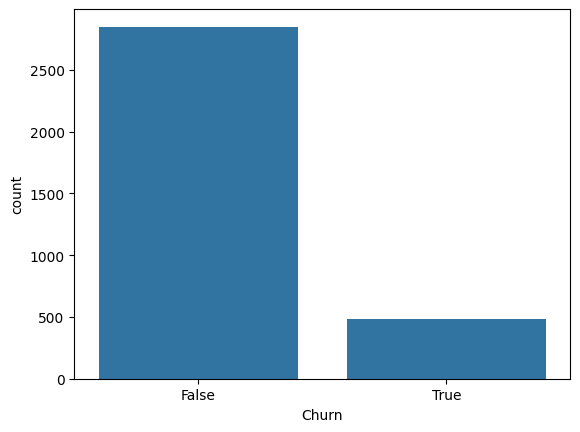

In [ ]:
# Value Counts
print(data_telco['Churn'].value_counts())

import seaborn as sns
sns.countplot(x = data_telco['Churn'])

In [ ]:
# 2. Data cleaning (missing values, outliers, duplicates, etc.)
# Dropping unwanted variables

data_telco_1 = data_telco.drop(['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan'], axis = 1)
data_telco_1

,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,0,213.8,105,36.35,159.6,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


In [ ]:
data_telco_1.isnull().sum()

Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [ ]:
# Variable assingment
x = data_telco_1.drop('Churn', axis = 1)
y = data_telco_1['Churn']

In [ ]:
# 4. Data split

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

**Oversampling vs. Undersampling**

**Oversampling** is a resampling technique that modifies the distribution of the target variable in the dataset by artificially increasing the number of observations.

There are two different types of oversampling methods.
1.   Duplicating existing entries that are already present in the dataset to increase the presence of those entries.
2.   Creating new “synthetic” observations that resemble the existing observations.

Advantages:
1.   Does not decrease the size of the dataset
2.   Does not lose any information

Disadvantage:
1.   Tendency to overfit




**Oversampling using SMOTE**

**SMOTE** stands for Synthetic Minority Over-sampling Technique.It is the most robust approaches for performing class balancing.

It creates synthetic samples by randomly sampling the characteristics from occurrences in the minority class.

To implement the SMOTE technique for class balancing, we can use the **imbalanced-learn** library which has many algorithms for this kind of problem.

<Axes: xlabel='Churn', ylabel='count'>

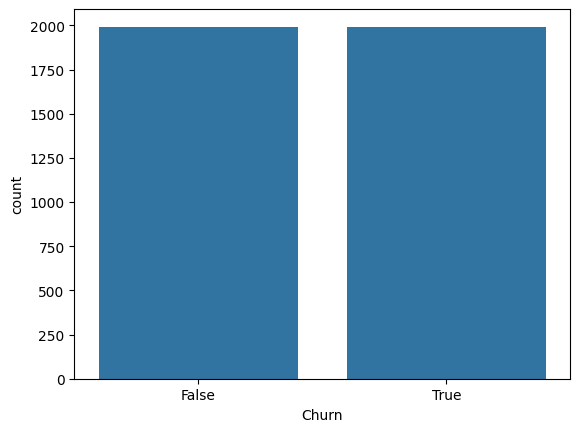

In [ ]:
# 6. Class Balancing
# %pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
x_b, y_b = SMOTE().fit_resample(x_train, y_train)
sns.countplot(x = y_b)

**Can also use ADASYN or RandomOverSampler to perform OVER SAMPLING**

RandomOverSampler

* How it works:
Simply duplicates minority class examples until class balance is achieved.

* Pros:
Very fast and simple.

* Cons:
Overfitting risk is high (since duplicates are exact).



ADASYN (Adaptive Synthetic Sampling)

* How it works:
Similar to SMOTE, but it focuses more on harder-to-learn examples (i.e., those closer to class boundaries).

* Pros:
Adaptive: generates more samples in harder areas.

* Cons:
More complex and potentially introduces more noise.
Risk of oversampling noisy/outlier points.

**Undersampling using Near Miss**

<Axes: xlabel='Churn', ylabel='count'>

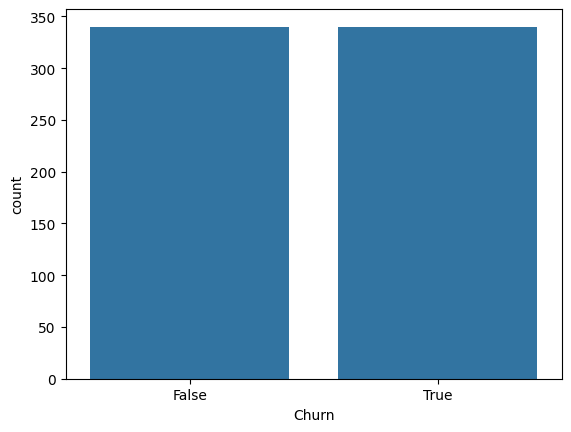

In [ ]:
from imblearn.under_sampling import NearMiss
nm = NearMiss()
x_nm, y_nm = nm.fit_resample(x_train, y_train)
sns.countplot(x = y_nm)

**SMOTEENN**
* SMOTE + Edited Nearest Neighbors (ENN)
* SMOTE creates synthetic samples.
* ENN removes noisy or borderline samples from the majority class.


<Axes: xlabel='Churn', ylabel='count'>

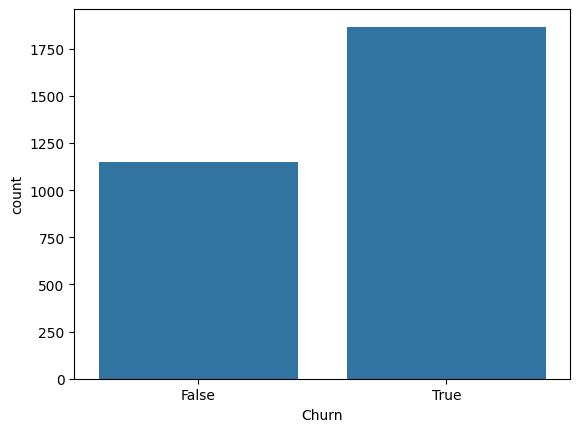

In [ ]:
from imblearn.combine import SMOTEENN
smote_enn = SMOTEENN(random_state = 42)
X_resampled, y_resampled = smote_enn.fit_resample(x_train, y_train)
sns.countplot(x = y_resampled)

In [ ]:
# 5. Feature encoding (x_train, x_test) (fit_transform on train, transform on test)
# Do this suitably as learnt earlier after performing the class balancing

**Pls follow this order:**
1. Data reading and understanding
2. Data cleaning (duplicates, etc.)
3. Data Split (train/test)
4. Impute missing values
5. Feature encoding (x_train, x_test) (fit_transform on train, transform on test)
6. TV labelling (fit_transform on train, transform on test)
6. Class Balancing (only on train data, not on test data)
7. Feature Scaling or Data normalization

### **Homework**

Select a preferred datset with around 10-15 variables.
 1. Perform EDA
 2. Perform Preprocessing
